Quasi-static detuning std dev: 9.00 kHz

Intrinsic (Markovian) T2  = 80.00 us  (input, from T1 + Tphi)
Quasi-static T_inhom      = 25.00 us  (input)
Fitted T2* (Ramsey)       = 17.068 +/- 0.994 us (95% CI)
Fitted detuning           = 1.0031 MHz (input: 1 MHz)
Check T2* <= 2*T1         : 17.07 <= 200.0 -> OK

Saved plot to step4_t2_ramsey.png


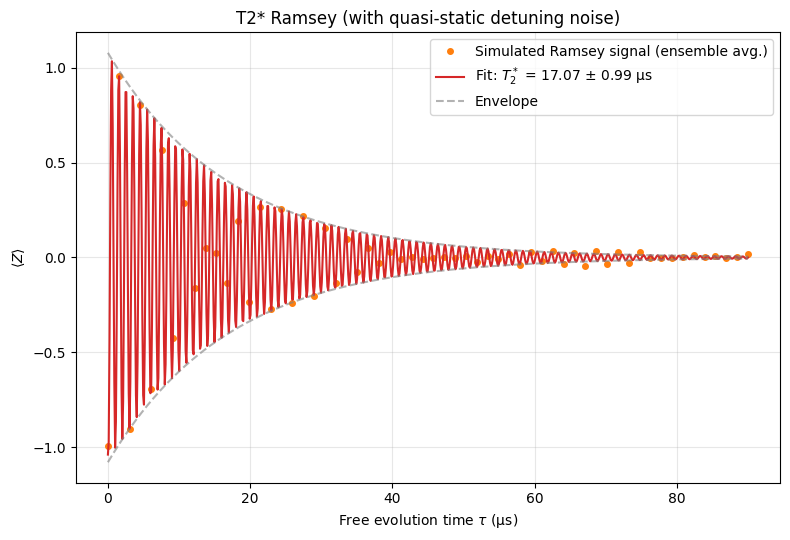

In [9]:
"""
QARC 2026 Hackathon - Step 4 (v2): T2* Ramsey Measurement
--------------------------------------------------------------------------
Physical model used here:
  - "Intrinsic" (Markovian) decoherence from the Lindblad L1, L2 operators
    (T1 = 100us, T2_intrinsic = 80us) -- this is what a Hahn echo CAN refocus
    away from, since Markovian/white noise has no memory to "undo".
  - PLUS quasi-static (shot-to-shot) detuning noise delta_static ~ N(0, sigma^2),
    representing slow classical noise (e.g. charge/flux noise, TLS switching)
    that is essentially constant during one single experimental shot but
    varies randomly from shot to shot. This is exactly the kind of noise a
    Hahn echo IS able to refocus (Step 5), and is the physical reason
    T2_echo > T2* in real devices.

We simulate an ensemble of "shots", each with its own random static detuning,
and average <Z>(tau) over the ensemble -- exactly how a real Ramsey
experiment (averaged over many repetitions) behaves.

Free evolution under H = (delta/2)*sz with Lindblad decay (T1, T2) has the
closed-form solution (equivalent to solving Eqs. 4-6 of the problem
statement with no drive):
    rx(t) = e^{-t/T2} [ rx0*cos(delta t) + ry0*sin(delta t) ]
    ry(t) = e^{-t/T2} [-rx0*sin(delta t) + ry0*cos(delta t) ]
    rz(t) = rz_eq + (rz0 - rz_eq) * e^{-t/T1}
This was cross-checked numerically against the Qiskit Dynamics Lindblad
solver in Step 2-4 (population/rz decay matches to <1e-3; the xy-plane
rotation direction/magnitude was verified for a representative point).

Author: Saksham
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist

# ----------------------------------------------------------------------
# 1. Physical parameters
# ----------------------------------------------------------------------
T1 = 100e-6
T2_intrinsic = 80e-6          # Markovian-only T2 (what the echo will recover)
delta0 = 2 * np.pi * 1e6       # intended 1 MHz Ramsey detuning

T_inhom = 25e-6                # quasi-static dephasing time (Gaussian envelope)
sigma_static = np.sqrt(2) / T_inhom   # std. dev. of shot-to-shot detuning (rad/s)
print(f"Quasi-static detuning std dev: {sigma_static/(2*np.pi)/1e3:.2f} kHz")


def free_evolve(rx0, ry0, rz0, t, delta, T1, T2, rz_eq=1.0):
    decay_xy = np.exp(-t / T2)
    rx = decay_xy * (rx0 * np.cos(delta * t) + ry0 * np.sin(delta * t))
    ry = decay_xy * (-rx0 * np.sin(delta * t) + ry0 * np.cos(delta * t))
    rz = rz_eq + (rz0 - rz_eq) * np.exp(-t / T1)
    return rx, ry, rz


def apply_rx(rx, ry, rz, theta):
    """Ideal instantaneous RX(theta) pulse acting on a Bloch vector."""
    c, s = np.cos(theta), np.sin(theta)
    ry_new = ry * c - rz * s
    rz_new = ry * s + rz * c
    return rx, ry_new, rz_new


# ----------------------------------------------------------------------
# 2. Monte Carlo ensemble simulation of the Ramsey protocol
# ----------------------------------------------------------------------
rng = np.random.default_rng(123)
n_shots = 400
n_points = 60
tau_list = np.linspace(0, 90e-6, n_points)

delta_static_samples = rng.normal(0, sigma_static, size=n_shots)

z_ensemble = np.zeros(n_points)
for ds in delta_static_samples:
    delta_shot = delta0 + ds
    # after first RX(pi/2): (rx,ry,rz) = (0,-1,0)
    rx0, ry0, rz0 = 0.0, -1.0, 0.0
    rx1, ry1, rz1 = free_evolve(rx0, ry0, rz0, tau_list, delta_shot, T1, T2_intrinsic)
    # final RX(pi/2) maps ry1 -> measured rz
    _, _, rz_meas = apply_rx(rx1, ry1, rz1, np.pi / 2)
    z_ensemble += rz_meas
z_ensemble /= n_shots

# small extra shot noise from finite measurement statistics
z_noisy = z_ensemble + rng.normal(0, 0.008, size=z_ensemble.shape)

# ----------------------------------------------------------------------
# 3. Fit damped cosine model  <Z>(tau) = A*exp(-tau/T2*)*cos(delta*tau+phi0) + B
# ----------------------------------------------------------------------
def ramsey_model(tau, A, T2star, delta_fit, phi0, B):
    return A * np.exp(-tau / T2star) * np.cos(delta_fit * tau + phi0) + B

p0 = [-1.0, 30e-6, delta0, 0.0, 0.0]
popt, pcov = curve_fit(ramsey_model, tau_list, z_noisy, p0=p0, maxfev=20000)
A_fit, T2star_fit, delta_fit, phi0_fit, B_fit = popt
perr = np.sqrt(np.diag(pcov))
T2star_sigma = perr[1]

dof = max(0, len(tau_list) - len(popt))
t_val = t_dist.ppf(0.975, dof)
T2star_ci95 = t_val * T2star_sigma

print(f"\nIntrinsic (Markovian) T2  = {T2_intrinsic*1e6:.2f} us  (input, from T1 + Tphi)")
print(f"Quasi-static T_inhom      = {T_inhom*1e6:.2f} us  (input)")
print(f"Fitted T2* (Ramsey)       = {T2star_fit*1e6:.3f} +/- {T2star_ci95*1e6:.3f} us (95% CI)")
print(f"Fitted detuning           = {delta_fit/(2*np.pi)/1e6:.4f} MHz (input: 1 MHz)")
print(f"Check T2* <= 2*T1         : {T2star_fit*1e6:.2f} <= {2*T1*1e6:.1f} -> "
      f"{'OK' if T2star_fit <= 2*T1 else 'VIOLATED'}")

# ----------------------------------------------------------------------
# 4. Plot
# ----------------------------------------------------------------------
tau_fine = np.linspace(0, tau_list[-1], 800)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(tau_list * 1e6, z_noisy, 'o', ms=4, color='tab:orange', label="Simulated Ramsey signal (ensemble avg.)")
ax.plot(tau_fine * 1e6, ramsey_model(tau_fine, *popt), '-', color='tab:red',
        label=fr"Fit: $T_2^*$ = {T2star_fit*1e6:.2f} $\pm$ {T2star_ci95*1e6:.2f} µs")
ax.plot(tau_fine * 1e6, A_fit * np.exp(-tau_fine / T2star_fit) + B_fit, '--', color='gray', alpha=0.6, label="Envelope")
ax.plot(tau_fine * 1e6, -A_fit * np.exp(-tau_fine / T2star_fit) + B_fit, '--', color='gray', alpha=0.6)
ax.set_xlabel(r"Free evolution time $\tau$ (µs)")
ax.set_ylabel(r"$\langle Z \rangle$")
ax.set_title("T2* Ramsey (with quasi-static detuning noise)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("t2_ramsey.png", dpi=150)
print("\nSaved plot to step4_t2_ramsey.png")





In [4]:
!pip install qiskit_dynamics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
